#**CAN LLMS REPLACE ANNOTATED DATA? SYNTHETIC DATA GENERATION FOR BIOMEDICAL NER**




**Author: Aitor Milicua Fernandez**

Trabajo indiviual para la asignatura de Mineria de Datos Textuales

## 0. PREPARAR ENTORNO


Instalar las dependencias y hacer imports

In [1]:
!pip install transformers datasets seqeval -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, AutoModelForCausalLM
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report

print("Torch version:", torch.__version__)
print("Dispositivo:", "GPU" if torch.cuda.is_available() else "CPU")

Torch version: 2.10.0+cu128
Dispositivo: GPU


Cargamos y analizamos el dataset que hemos elegido para el trabajo

In [3]:
from huggingface_hub import login
login()


In [4]:
data_files = {
    "train": "https://huggingface.co/datasets/tner/bc5cdr/resolve/main/dataset/train.json",
    "validation": "https://huggingface.co/datasets/tner/bc5cdr/resolve/main/dataset/valid.json",
    "test": "https://huggingface.co/datasets/tner/bc5cdr/resolve/main/dataset/test.json",
}

dataset = load_dataset("json", data_files=data_files)


train.json: 0.00B [00:00, ?B/s]

valid.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
# dataset = load_dataset("tner/bc5cdr")

In [5]:
# Ver un ejemplo del train
ejemplo = dataset["train"][0]
print("Tokens:", ejemplo["tokens"])
print("Etiquetas:", ejemplo["tags"])

Tokens: ['Naloxone', 'reverses', 'the', 'antihypertensive', 'effect', 'of', 'clonidine', '.']
Etiquetas: [1, 0, 0, 0, 0, 0, 1, 0]


In [6]:
# Ver qué etiquetas existen
features = dataset["train"].features
print(dataset["train"][0]["tags"])

[1, 0, 0, 0, 0, 0, 1, 0]


Cargamos el modelo biobert

In [7]:
MODEL_NAME_ner = "dmis-lab/biobert-base-cased-v1.2"

tokenizer_ner = AutoTokenizer.from_pretrained(MODEL_NAME_ner)
print("Tokenizer cargado")

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizer cargado


In [8]:
label_list = ['O', 'B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease']
num_labels = len(label_list)

model_ner = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME_ner,
    num_labels=num_labels
)
print(f"Modelo cargado: {num_labels} etiquetas")
print(label_list)

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

Modelo cargado: 5 etiquetas
['O', 'B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease']


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

In [9]:
# Verificar el mapping correcto
ejemplo = dataset["train"][0]
print("Tokens:", ejemplo["tokens"])
print("Tags (numérico):", ejemplo["tags"])

# Con el label_list correcto
label_list = ['O', 'B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease']
etiquetas_texto = [label_list[t] for t in ejemplo["tags"]]
print("Tags (texto):", etiquetas_texto)

Tokens: ['Naloxone', 'reverses', 'the', 'antihypertensive', 'effect', 'of', 'clonidine', '.']
Tags (numérico): [1, 0, 0, 0, 0, 0, 1, 0]
Tags (texto): ['B-Chemical', 'O', 'O', 'O', 'O', 'O', 'B-Chemical', 'O']


## 1. CONFIGURACION DE LA API DE GEMINI

De primeras iba a usar el modelo gemini-2.0-flash para la generación de ejemplos, pero por temas de rate limiting, he decidido usar el modelo Qween de HuggingFace. Finalmente por problemas con los créditos de HuggingFace, voy a utilizar un modelo Qwen de manera local

In [10]:
!pip install google-generativeai -q
!pip install huggingface_hub -q
!pip install transformers accelerate bitsandbytes -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.2 MB/s eta 0:00:00:00:0100:01


In [11]:
MODEL_ID_gen = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID_gen)
model_gen = AutoModelForCausalLM.from_pretrained(
    MODEL_ID_gen,
    dtype=torch.float16,
    device_map="auto"
)
print("Qwen 3B cargado")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen 3B cargado


Definimos los 3 prompts que vamos a usar Zero Shot, Few Shot con entidades aisladas y Few Shot con ejemplos del train

In [17]:
# Etiquetas disponibles
LABEL_DESCRIPTION = """
- Chemical: químico, fármaco o sustancia biomédica
- Disease: enfermedad, trastorno o condición médica
"""

# PROMPT 1: Zero-shot
PROMPT_ZERO_SHOT = """
You are a biomedical
NER data generator.
Generate one synthetic biomedical mini-abstract with named entity annotations.

The abstract must follow this exact JSON format:
{{
  "text": "biomedical abstract text here",
  "entities": [
    {{"text": "entity mention", "label": "Chemical"}},
    {{"text": "entity mention", "label": "Disease"}}
  ]
}}

Entity labels:
{label_description}

Rules:
- Output only valid JSON, nothing else.
- The text must contain between 40 and 80 words. Do not exceed 80 words.
- Include at least 2 Chemical entities and 2 Disease entities.
- Each entity in the entities list must appear exactly in the text.
- Labels must be only "Chemical" or "Disease".
- Avoid repeatedly using aspirin, ibuprofen, hypertension, diabetes, rheumatoid arthritis, and osteoarthritis.
- Use rare and diverse biomedical entities. Prefer different drugs, compounds, diseases, cancers, neurological disorders, infections, inflammatory diseases, and metabolic disorders across generations.
-Do not reuse the same biomedical scenario across generations.
-Vary the diseases, chemicals, study context, and sentence structure.
-Avoid generating multiple examples about the same treatment-disease pair.
""".format(label_description=LABEL_DESCRIPTION)


# PROMPT 2: Few-shot A con entidades aisladas
PROMPT_FEW_SHOT_A = """
You are a biomedical NER data generator.
Generate one synthetic biomedical mini-abstract with named entity annotations.

The abstract must follow this exact JSON format:
{{
  "text": "biomedical abstract text here",
  "entities": [
    {{"text": "entity mention", "label": "Chemical"}},
    {{"text": "entity mention", "label": "Disease"}}
  ]
}}

Entity labels:
{label_description}

Examples of correctly annotated entities:
- "aspirin" → Chemical
- "myocardial infarction" → Disease
- "metformin" → Chemical
- "Parkinson disease" → Disease

Rules:
- Output only valid JSON, nothing else.
- The text must contain between 40 and 80 words. Do not exceed 80 words.
- Include at least 2 Chemical entities and 2 Disease entities.
- Each entity in the entities list must appear exactly in the text.
- Labels must be only "Chemical" or "Disease".
- Avoid repeatedly using aspirin, ibuprofen, hypertension, diabetes, rheumatoid arthritis, and osteoarthritis.
-Use rare and diverse biomedical entities. Prefer different drugs, compounds, diseases, cancers, neurological disorders, infections, inflammatory diseases, and metabolic disorders across generations.
-Do not reuse the same biomedical scenario across generations.
-Vary the diseases, chemicals, study context, and sentence structure.
-Avoid generating multiple examples about the same treatment-disease pair.
""".format(label_description=LABEL_DESCRIPTION)


# PROMPT 3: Few-shot B con ejemplos del train
ejemplo_train = dataset["train"][0]
ejemplo_texto = " ".join(ejemplo_train["tokens"])

label_list = ['O', 'B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease']
ejemplo_tags = [label_list[t] for t in ejemplo_train["tags"]]

PROMPT_FEW_SHOT_B = """
You are a biomedical NER data generator.
Generate one synthetic biomedical mini-abstract with named entity annotations.

The abstract must follow this exact JSON format:
{{
  "text": "biomedical abstract text here",
  "entities": [
    {{"text": "entity mention", "label": "Chemical"}},
    {{"text": "entity mention", "label": "Disease"}}
  ]
}}

Entity labels:
{label_description}

Here is a real annotated example from a biomedical corpus:
Text: {texto}
Tags: {tags}

Rules:
- Output only valid JSON, nothing else.
- The text must contain between 40 and 80 words. Do not exceed 80 words.
- Include at least 2 Chemical entities and 2 Disease entities.
- Each entity in the entities list must appear exactly in the text.
- Labels must be only "Chemical" or "Disease".
- Avoid repeatedly using aspirin, ibuprofen, hypertension, diabetes, rheumatoid arthritis, and osteoarthritis.
- Use rare and diverse biomedical entities. Prefer different drugs, compounds, diseases, cancers, neurological disorders, infections, inflammatory diseases, and metabolic disorders across generations.
- Do not copy the example literally.
-Do not reuse the same biomedical scenario across generations.
-Vary the diseases, chemicals, study context, and sentence structure.
-Avoid generating multiple examples about the same treatment-disease pair.
""".format(
    label_description=LABEL_DESCRIPTION,
    texto=ejemplo_texto,
    tags=ejemplo_tags
)

In [16]:
import json
import re

def extraer_json(text):
    text = text.strip()

    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?", "", text.strip())
        text = re.sub(r"```$", "", text.strip())

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1:
        raise ValueError("No se encontró JSON válido")

    return text[start:end+1]

def call_model(prompt):
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer([text], return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=3000,
            temperature=0.3,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    generated = outputs[0][inputs.input_ids.shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

print("Función call_model local lista")

def convertir_a_iob2(data):
    texto = data["text"]
    entidades = data["entities"]

    tokens = re.findall(r"\w+|[^\w\s]", texto)
    tags = ["O"] * len(tokens)
    tokens_lower = [t.lower() for t in tokens]

    for entidad in entidades:
        ent_text = entidad["text"]
        label = entidad["label"]

        if label not in ["Chemical", "Disease"]:
            raise ValueError(f"Label inválida: {label}")

        ent_tokens = re.findall(r"\w+|[^\w\s]", ent_text)
        ent_tokens_lower = [t.lower() for t in ent_tokens]

        encontrada = False

        # Intento 1: coincidencia exacta case-insensitive
        for i in range(len(tokens) - len(ent_tokens) + 1):
            if tokens_lower[i:i+len(ent_tokens)] == ent_tokens_lower:
                tags[i] = f"B-{label}"
                for j in range(1, len(ent_tokens)):
                    tags[i+j] = f"I-{label}"
                encontrada = True
                break

        # Intento 2: coincidencia por prefijo (cubre plurales y variantes morfológicas)
        if not encontrada and len(ent_tokens) == 1:
            prefijo = ent_tokens_lower[0][:5]  #
            for i in range(len(tokens_lower)):
                if tokens_lower[i].startswith(prefijo) and len(tokens_lower[i]) >= len(prefijo):
                    tags[i] = f"B-{label}"
                    encontrada = True
                    break

        if not encontrada:
            raise ValueError(f"Entidad no encontrada en texto: {ent_text}")

    return {
        "tokens": tokens,
        "tags": tags
    }



Función call_model local lista


## 2. GENERACION DE DATOS SINTETICOS

**Mediante las siguientes funciones vamos a generar los datos.**

COn la funcion generar_abstract vamos a llamar al modelo y validar el resultado, con un total de 3 intentos si algo falla. Tambien vamos a descartar respuestas demasiado cortas

In [18]:
import time

def generar_abstract(prompt, max_reintentos=3):
    for intento in range(max_reintentos):
        try:
            raw = call_model(prompt)
            text = extraer_json(raw)
            data = json.loads(text)

            if "text" not in data or "entities" not in data:
                raise ValueError("Faltan claves text/entities")

            resultado = convertir_a_iob2(data)

            tokens = resultado["tokens"]
            tags = resultado["tags"]

            if len(tokens) < 20:
                raise ValueError(f"Abstract corto: {len(tokens)} tokens")

            if len(tokens) > 90:
                raise ValueError(f"Abstract demasiado largo: {len(tokens)} tokens")

            num_chemicals = sum(1 for t in tags if t == "B-Chemical")
            num_diseases = sum(1 for t in tags if t == "B-Disease")


            if num_chemicals< 1 or num_diseases < 1:
                raise ValueError(f"Pocas entidades Chemical: {num_chemicals}, Disease: {lnum_diseases}")

            return resultado

        except Exception as e:
            print(f"  Intento {intento+1} fallido: {e}")
            time.sleep(1)

    return None

Funcion para crear el corpus dependiendo del propmt y la cantidad de ejemplos a generar

In [19]:
def generar_corpus(prompt, n, nombre_prompt):
    corpus = []
    fallos = 0
    print(f"Generando {n} abstracts con {nombre_prompt}...")
    for i in range(n):
        resultado = generar_abstract(prompt)
        if resultado is not None:
            corpus.append(resultado)
        else:
            fallos += 1
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{n} — OK: {len(corpus)}, Fallos: {fallos}")
        if (i + 1) % 100 == 0:
            guardar_corpus(corpus, f"corpus_{nombre_prompt}_parcial.json")
            print(f"  Guardado parcial: {len(corpus)} abstracts")
        time.sleep(0.5)
    print(f"Completado: {len(corpus)} válidos, {fallos} fallos")
    return corpus
print("ejecutado")

ejecutado


Vamos a crear **tres grupos de corpus**. Para **cada tipo de prompt** que vamos a usar vamos a generar **gorpus de 100, 500 y 1000 ejemplos**. El objetivo es comprobar y **analizar la curva de aprendizaje** entre usar pocos ejemplso (100 considero que son muy pocos), un rango medio (500) y uno elevado (1000) para ver si el desempeño mejora y la inlfuencia que tiene esto.

In [19]:
import json
def guardar_corpus(corpus, path):
    with open(path, "w") as f:
        json.dump(corpus, f)
    print(f"Guardado: {path} ({len(corpus)} abstracts)")

In [40]:
corpus_prueba_local=generar_corpus(PROMPT_FEW_SHOT_B, 1, "few-shot-B")

Generando 1 abstracts con few-shot-B...
Completado: 1 válidos, 0 fallos


**Por problemas y exceso de tiempo, he decidido que voy a usar el segundo tipo de few shot, el de ejemplos del train, con 3 cantidades de datos: 100, 500 y 800. Para probar la diferencia de calidad entre propmts, voy a generar 800 ejemplos de cada tipo de prompt.**

In [ ]:
corpus_fsb_100 = generar_corpus(PROMPT_FEW_SHOT_B, 100, "few-shot-B")
guardar_corpus(corpus_fsb_100, "corpus_fewshot_b_100.json")

In [ ]:
corpus_fsb_500 = generar_corpus(PROMPT_FEW_SHOT_B, 500, "few-shot-B")
guardar_corpus(corpus_fsb_500, "corpus_fewshot_b_500.json")

print("500 HECHO")

In [44]:
corpus_fsb_800 = generar_corpus(PROMPT_FEW_SHOT_B, 800, "few-shot-B")
guardar_corpus(corpus_fsb_800, "corpus_fewshot_b_800.json")
print("====CORPUS PARA EXPERIMENTO DE CANTIDADES DIFERENTES CON MISMO PROMPT (FEW-SHOT B)TERMIANDO ===")


Generando 800 abstracts con few-shot-B...
  Intento 1 fallido: Abstract corto: 19 tokens
  Intento 1 fallido: Abstract corto: 16 tokens
  Intento 1 fallido: Abstract corto: 14 tokens
  10/800 — OK: 10, Fallos: 0
  Intento 1 fallido: Abstract corto: 19 tokens
  20/800 — OK: 20, Fallos: 0
  Intento 1 fallido: Abstract corto: 15 tokens
  Intento 2 fallido: Abstract corto: 18 tokens
  Intento 1 fallido: Abstract corto: 18 tokens
  Intento 1 fallido: Abstract corto: 16 tokens
  Intento 2 fallido: Abstract corto: 19 tokens
  30/800 — OK: 30, Fallos: 0
  Intento 1 fallido: Abstract corto: 18 tokens
  Intento 1 fallido: Abstract corto: 17 tokens
  Intento 2 fallido: Abstract corto: 17 tokens
  Intento 1 fallido: Abstract corto: 14 tokens
  Intento 1 fallido: Abstract corto: 15 tokens
  Intento 1 fallido: Abstract corto: 18 tokens
  Intento 2 fallido: Abstract corto: 15 tokens
  Intento 3 fallido: Abstract corto: 18 tokens
  Intento 1 fallido: Abstract corto: 18 tokens
  40/800 — OK: 39, Fallos

In [45]:
corpus_fsa_800 = generar_corpus(PROMPT_FEW_SHOT_A, 800, "few-shot-A")
guardar_corpus(corpus_fsa_800, "corpus_fewshot_a_800.json")


Generando 800 abstracts con few-shot-A...
  10/800 — OK: 10, Fallos: 0
  20/800 — OK: 20, Fallos: 0
  30/800 — OK: 30, Fallos: 0
  40/800 — OK: 40, Fallos: 0
  50/800 — OK: 50, Fallos: 0
  60/800 — OK: 60, Fallos: 0
  70/800 — OK: 70, Fallos: 0
  80/800 — OK: 80, Fallos: 0
  90/800 — OK: 90, Fallos: 0
  100/800 — OK: 100, Fallos: 0
Guardado: corpus_few-shot-A_parcial.json (100 abstracts)
  Guardado parcial: 100 abstracts
  Intento 1 fallido: Entidad no encontrada en texto: favouripiravir
  110/800 — OK: 110, Fallos: 0
  120/800 — OK: 120, Fallos: 0
  130/800 — OK: 130, Fallos: 0
  140/800 — OK: 140, Fallos: 0
  150/800 — OK: 150, Fallos: 0
  160/800 — OK: 160, Fallos: 0
  170/800 — OK: 170, Fallos: 0
  180/800 — OK: 180, Fallos: 0
  190/800 — OK: 190, Fallos: 0
  200/800 — OK: 200, Fallos: 0
Guardado: corpus_few-shot-A_parcial.json (200 abstracts)
  Guardado parcial: 200 abstracts
  210/800 — OK: 210, Fallos: 0
  220/800 — OK: 220, Fallos: 0
  230/800 — OK: 230, Fallos: 0
  240/800 — O

In [46]:
corpus_zs_800 = generar_corpus(PROMPT_ZERO_SHOT, 800, "zero-shot")
guardar_corpus(corpus_zs_800, "corpus_zeroshot_800.json")
print("====CORPUS DE 800 EJEMPLOS CREADO PARA CADA PROMPT===")


Generando 800 abstracts con zero-shot...
  10/800 — OK: 10, Fallos: 0
  20/800 — OK: 20, Fallos: 0
  30/800 — OK: 30, Fallos: 0
  40/800 — OK: 40, Fallos: 0
  50/800 — OK: 50, Fallos: 0
  60/800 — OK: 60, Fallos: 0
  70/800 — OK: 70, Fallos: 0
  80/800 — OK: 80, Fallos: 0
  90/800 — OK: 90, Fallos: 0
  100/800 — OK: 100, Fallos: 0
Guardado: corpus_zero-shot_parcial.json (100 abstracts)
  Guardado parcial: 100 abstracts
  110/800 — OK: 110, Fallos: 0
  120/800 — OK: 120, Fallos: 0
  130/800 — OK: 130, Fallos: 0
  140/800 — OK: 140, Fallos: 0
  150/800 — OK: 150, Fallos: 0
  160/800 — OK: 160, Fallos: 0
  170/800 — OK: 170, Fallos: 0
  180/800 — OK: 180, Fallos: 0
  190/800 — OK: 190, Fallos: 0
  200/800 — OK: 200, Fallos: 0
Guardado: corpus_zero-shot_parcial.json (200 abstracts)
  Guardado parcial: 200 abstracts
  210/800 — OK: 210, Fallos: 0
  220/800 — OK: 220, Fallos: 0
  230/800 — OK: 230, Fallos: 0
  240/800 — OK: 240, Fallos: 0
  250/800 — OK: 250, Fallos: 0
  Intento 1 fallido: A

## 3. FINE-TUNING DE BIOBERT



Mapeo de etiquetas y separacion del conjunto de train y test



In [15]:
import pandas as pd
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification
from datasets import Dataset
from seqeval.metrics import f1_score, precision_score, recall_score
import numpy as np

In [16]:
tokenizer_ner = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.2")

label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}

bc5cdr_train = dataset["train"]
bc5cdr_test  = dataset["test"]

print(f"BC5CDR longitud train: {len(bc5cdr_train)} y test: {len(bc5cdr_test)}")


BC5CDR longitud train: 5228 y test: 5865


BioBERT opera a nivel de subpalabras (wordpieces), no de palabras completas. Esto significa que una palabra como "aspirin" puede dividirse en varios tokens internos. Esta función tokeniza las secuencias y alinea las etiquetas NER con los subtoken resultantes: el primer subtoken de cada palabra recibe la etiqueta original, el resto recibe -100 para ser ignorado durante el cálculo de la pérdida.

In [18]:
def tokenize_and_align_labels(examples):
    tokenized = tokenizer_ner(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=128,
        padding="max_length"
    )
    labels = []
    for i, label in enumerate(examples["tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        prev_word_id = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(label[word_id])
            else:
                label_ids.append(-100)
            prev_word_id = word_id
        labels.append(label_ids)
    tokenized["labels"] = labels
    return tokenized

Definimos las métricas de evaluación estándar para NER: F1, Precision y Recall a nivel de entidad completa (span exacto), calculadas con la librería seqeval. Una entidad solo se considera correcta si tanto su span como su tipo coinciden exactamente con la anotación de referencia. Esta es la métrica estándar en benchmarks biomédicos como BC5CDR.

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=2)

    true_labels = [
        [label_list[l] for l in row if l != -100]
        for row in labels
    ]
    true_preds = [
        [label_list[p] for p, l in zip(pred_row, label_row) if l != -100]
        for pred_row, label_row in zip(predictions, labels)
    ]

    return {
        "f1":        f1_score(true_labels, true_preds),
        "precision": precision_score(true_labels, true_preds),
        "recall":    recall_score(true_labels, true_preds),
    }


La siguiente funcion nos sirve para definir el pipleine de fine-tuning y evaluacion. Cargamos el BioBERT desde cero, y lo entrenamos sobre el corpus 5 epocas (los corpus son los generados anteriormente para probar la diferencia entre few-shots y el dataset real creado por humanos). Utilizamos siempre el mismo test split apra que los resultados sean comparables entre los modelos

In [20]:
def entrenar_y_evaluar(train_dataset, nombre, epochs=5):
   
    print(f"Entrenando {nombre} con {len(train_dataset)} ejemplos\n")
    
    train_tok = train_dataset.map(tokenize_and_align_labels, batched=True)
    test_tok  = bc5cdr_test.map(tokenize_and_align_labels, batched=True)

    model_ft = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME_ner,
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    args = TrainingArguments(
        output_dir=f"./results_{nombre}",
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_steps=100,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )

    data_collator = DataCollatorForTokenClassification(tokenizer_ner)

    trainer = Trainer(
        model=model_ft,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
    
    trainer.train()
    res = trainer.evaluate()
    print(f"F1: {res['eval_f1']:.4f} | P: {res['eval_precision']:.4f} | R: {res['eval_recall']:.4f}")
    return res

print("FUncion de entrenar lista")

FUncion de entrenar lista


### 3.1 Entrenamiento con el baseline

In [21]:
res_baseline = entrenar_y_evaluar(bc5cdr_train, "baseline_bc5cdr")

Entrenando baseline_bc5cdr con 5228 ejemplos



Map:   0%|          | 0/5228 [00:00<?, ? examples/s]

Map:   0%|          | 0/5865 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.188781,0.157151,0.857998,0.835796,0.881412
2,0.096326,0.144884,0.877587,0.873052,0.882170
3,0.050730,0.175235,0.877478,0.847524,0.909627
4,0.028204,0.185134,0.884382,0.867785,0.901626
5,0.020210,0.200701,0.884639,0.867969,0.901962


F1: 0.8846 | P: 0.8680 | R: 0.9020


Entrenamos los modelos experimentales sobre los corpus sintéticos generados mediante instruct prompting. El experimento tiene dos partes:el de diferentes tamaños de corpus para el FewShot B (FSB a 100/500/800 ejemplos) mide si más datos sintéticos mejoran el rendimiento, yla parte de difrerentes prompts (ZS/FSA/FSB a 800 ejemplos) para ver si la estrategia de prompting afecta a la calidad de los datos generados.

In [28]:
import json
from datasets import Dataset

def cargar_corpus(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def corpus_to_dataset(corpus):
    return Dataset.from_dict({
        "tokens": [item["tokens"] for item in corpus],
        "tags":   [[label2id[t] for t in item["tags"]] for item in corpus]
    })

# Cargar archivos JSON desde Kaggle
zs_800 = cargar_corpus("/kaggle/input/datasets/aaitorm/zero-shot-corpus/zs.json")
fsb_800 = cargar_corpus("/kaggle/input/datasets/aaitorm/fsb-corpus/fsb.json")
fsa_800 = cargar_corpus("/kaggle/input/datasets/aaitorm/fsa-corpus/fsa.json")

# Convertir a Dataset de Hugging Face
zs_dataset = corpus_to_dataset(zs_800)
fsb_dataset = corpus_to_dataset(fsb_800)
fsa_dataset = corpus_to_dataset(fsa_800)

print("Modelos/corpus cargados correctamente")
print(zs_dataset)
print(fsb_dataset)
print(fsa_dataset)

Modelos/corpus cargados correctamente
Dataset({
    features: ['tokens', 'tags'],
    num_rows: 800
})
Dataset({
    features: ['tokens', 'tags'],
    num_rows: 781
})
Dataset({
    features: ['tokens', 'tags'],
    num_rows: 800
})


###  3.2 Entrenamiento con diferentes tamaños de los datos generados con Few Shot B

In [29]:
res_fsb_100 = entrenar_y_evaluar(corpus_to_dataset(fsb_800[:100]), "fsb_100")

Entrenando fsb_100 con 100 ejemplos



Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,3.310077,0.064299,0.036864,0.251411
2,No log,3.214491,0.064941,0.037636,0.236587
3,No log,3.054852,0.066149,0.039680,0.198686
4,No log,2.840124,0.066915,0.045543,0.126084
5,No log,2.578656,0.035878,0.040281,0.032342


F1: 0.0359 | P: 0.0403 | R: 0.0323


In [30]:
res_fsb_500 = entrenar_y_evaluar(corpus_to_dataset(fsb_800[:500]), "fsb_500")
print("===Modelos de Few Shot B entrenados===")

Entrenando fsb_500 con 500 ejemplos



Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,2.742095,0.050840,0.035056,0.092479
2,No log,1.398113,0.000335,0.035714,0.000168
3,No log,0.948548,0.010637,0.186782,0.005475
4,1.968618,0.850122,0.117673,0.468073,0.067296
5,1.968618,0.780158,0.322384,0.554096,0.227322


F1: 0.3224 | P: 0.5541 | R: 0.2273
===Modelos de Few Shot B entrenados===


In [31]:
res_fsb_800 = entrenar_y_evaluar(corpus_to_dataset(fsb_800), "fsb_800")


Entrenando fsb_800 con 781 ejemplos



Map:   0%|          | 0/781 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,2.009225,0.002162,0.012975,0.001179
2,1.958910,0.939654,0.024443,0.236842,0.012886
3,1.958910,0.818900,0.284574,0.574131,0.189169
4,0.264796,0.780783,0.386216,0.622868,0.279879
5,0.264796,0.810783,0.370456,0.677333,0.254948


F1: 0.3705 | P: 0.6773 | R: 0.2549


### 3.3 Entrenamiento con diferentes prompts

In [32]:
res_zs_800  = entrenar_y_evaluar(corpus_to_dataset(zs_800),  "zeroshot_800")

Entrenando zeroshot_800 con 800 ejemplos



Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,1.987369,0.001402,0.009356,0.000758
2,1.761398,0.806687,0.185643,0.886249,0.103681
3,1.761398,0.741794,0.355666,0.805110,0.228249
4,0.180936,0.760080,0.339783,0.656062,0.229260
5,0.180936,0.772185,0.317553,0.693420,0.205929


F1: 0.3176 | P: 0.6934 | R: 0.2059


In [33]:

res_fsa_800 = entrenar_y_evaluar(corpus_to_dataset(fsa_800), "fewshot_a_800")

print("===Modelos de Few Shot diferentes entrenados====")


Entrenando fewshot_a_800 con 800 ejemplos



Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,1.971264,0.001558,0.010363,0.000842
2,1.822635,0.759083,0.215545,0.843588,0.123558
3,1.822635,0.764390,0.298849,0.711210,0.189169
4,0.178463,0.774592,0.331950,0.655327,0.222269
5,0.178463,0.788578,0.339150,0.626845,0.232460


F1: 0.3391 | P: 0.6268 | R: 0.2325
===Modelos de Few Shot diferentes entrenados====


Consolidamos los resultados de todos los experimentos en una tabla comparativa. Esta tabla es la pieza central del informe: muestra la brecha de rendimiento entre datos reales y sintéticos, el efecto del volumen y el efecto del diseño del prompt.

In [36]:
print(f"Test set cargado: {len(bc5cdr_test)} ejemplos")
print(f"Train set cargado: {len(bc5cdr_train)} ejemplos")

Test set cargado: 5865 ejemplos
Train set cargado: 5228 ejemplos


In [35]:
resultados = {
    "Baseline (BC5CDR real)": res_baseline,
    "Sintético ZS-800":       res_zs_800,
    "Sintético FSA-800":      res_fsa_800,
    "Sintético FSB-100":      res_fsb_100,
    "Sintético FSB-500":      res_fsb_500,
    "Sintético FSB-800":      res_fsb_800,
}

df = pd.DataFrame([{
    "Modelo":    nombre,
    "F1":        round(r["eval_f1"], 4),
    "Precision": round(r["eval_precision"], 4),
    "Recall":    round(r["eval_recall"], 4),
} for nombre, r in resultados.items()])

print(df.to_string(index=False))
df.to_csv("/kaggle/working/resultados_finales.csv", index=False)

                Modelo     F1  Precision  Recall
Baseline (BC5CDR real) 0.8846     0.8680  0.9020
      Sintético ZS-800 0.3176     0.6934  0.2059
     Sintético FSA-800 0.3391     0.6268  0.2325
     Sintético FSB-100 0.0359     0.0403  0.0323
     Sintético FSB-500 0.3224     0.5541  0.2273
     Sintético FSB-800 0.3705     0.6773  0.2549


## 4. ANALISIS DE ERRORES

Con los resultados obtenidos en el apartado anterior, vamos a analizar los errores del mejor modelo sintetico. Nuestro objetivo es ver que tipos de fallos cometes como pueden ser entidades no detectadas, falsos positivos, confusiones entre Chemical y Diesase, y errores de span parcial. Este analisis lo considero esencial para entender las limitaciones y complementar las metricas.

In [38]:
mejor_sintetico = max(
    {
        "FSB-100": res_fsb_100["eval_f1"],
        "FSB-500": res_fsb_500["eval_f1"],
        "FSB-800": res_fsb_800["eval_f1"],
        "ZS-800":  res_zs_800["eval_f1"],
        "FSA-800": res_fsa_800["eval_f1"],
    }.items(),
    key=lambda x: x[1]
)
print(f"Mejor modelo sintético: {mejor_sintetico[0]} con F1={mejor_sintetico[1]:.4f}")

Mejor modelo sintético: FSB-800 con F1=0.3705


Reentrenamos el mejor modelo sintético para obtener sus predicciones sobre el test set de BC5CDR. Guardamos tanto las predicciones como las etiquetas reales para el análisis posterior.

In [39]:
def obtener_predicciones(train_dataset, nombre, epochs=5):
    print(f"Reentrenando {nombre} para análisis de errores...")

    train_tok = train_dataset.map(tokenize_and_align_labels, batched=True)
    test_tok  = bc5cdr_test.map(tokenize_and_align_labels, batched=True)

    model_ft = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME_ner,
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    args = TrainingArguments(
        output_dir=f"./results_analisis_{nombre}",
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_steps=100,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )

    trainer = Trainer(
        model=model_ft,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        data_collator=DataCollatorForTokenClassification(tokenizer_ner),
        compute_metrics=compute_metrics
    )

    trainer.train()

    predictions_output = trainer.predict(test_tok)
    logits = predictions_output.predictions
    labels = predictions_output.label_ids
    preds  = np.argmax(logits, axis=2)

    true_labels = [
        [label_list[l] for l in row if l != -100]
        for row in labels
    ]
    true_preds = [
        [label_list[p] for p, l in zip(pred_row, label_row) if l != -100]
        for pred_row, label_row in zip(preds, labels)
    ]

    return true_labels, true_preds

corpus_mejor = fsb_800 

true_labels, true_preds = obtener_predicciones(
    corpus_to_dataset(corpus_mejor),
    "mejor_sintetico"
)

Reentrenando mejor_sintetico para análisis de errores...


Map:   0%|          | 0/781 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,2.009225,0.002162,0.012975,0.001179
2,1.958910,0.939654,0.024443,0.236842,0.012886
3,1.958910,0.818900,0.284574,0.574131,0.189169
4,0.264796,0.780783,0.386216,0.622868,0.279879
5,0.264796,0.810783,0.370456,0.677333,0.254948


Generamos el reporte detallado por tipo de entidad usando seqeval, que desglosa F1, Precision y Recall por separado para Chemical y Disease. Esto permite identificar si el modelo falla más en un tipo de entidad que en otro. Tambien, clasificamos los errores del modelo en cuatro categorías: falsos negativos (entidades reales no detectadas), falsos positivos (tokens marcados como entidad cuando no lo son), confusión de tipo (entidad detectada pero con la etiqueta incorrecta) y errores de span parcial (entidad detectada pero con límites incorrectos).

In [40]:
print("=== REPORTE DETALLADO MEJOR MODELO SINTÉTICO ===\n")
print(classification_report(true_labels, true_preds))

=== REPORTE DETALLADO MEJOR MODELO SINTÉTICO ===

              precision    recall  f1-score   support

    Chemical       0.78      0.39      0.52      7115
     Disease       0.27      0.05      0.09      4758

   micro avg       0.68      0.25      0.37     11873
   macro avg       0.53      0.22      0.30     11873
weighted avg       0.58      0.25      0.35     11873



In [41]:
fn_chemical = 0  # Falsos negativos Chemical
fn_disease   = 0  # Falsos negativos Disease
fp_chemical  = 0  # Falsos positivos Chemical
fp_disease   = 0  # Falsos positivos Disease
confusion    = 0  # Confusión Chemical <-> Disease

for true_seq, pred_seq in zip(true_labels, true_preds):
    for t, p in zip(true_seq, pred_seq):
        # Falsos negativos
        if t == "B-Chemical" and p == "O":
            fn_chemical += 1
        if t == "B-Disease" and p == "O":
            fn_disease += 1
        # Falsos positivos
        if t == "O" and p == "B-Chemical":
            fp_chemical += 1
        if t == "O" and p == "B-Disease":
            fp_disease += 1
        # Confusión de tipo
        if t == "B-Chemical" and p == "B-Disease":
            confusion += 1
        if t == "B-Disease" and p == "B-Chemical":
            confusion += 1

print("=== ANÁLISIS DE ERRORES POR TIPO ===\n")
print(f"Falsos negativos Chemical (no detectados):  {fn_chemical}")
print(f"Falsos negativos Disease  (no detectados):  {fn_disease}")
print(f"Falsos positivos Chemical (marcados de más): {fp_chemical}")
print(f"Falsos positivos Disease  (marcados de más): {fp_disease}")
print(f"Confusión Chemical <-> Disease:              {confusion}")

=== ANÁLISIS DE ERRORES POR TIPO ===

Falsos negativos Chemical (no detectados):  2434
Falsos negativos Disease  (no detectados):  3978
Falsos positivos Chemical (marcados de más): 532
Falsos positivos Disease  (marcados de más): 168
Confusión Chemical <-> Disease:              111


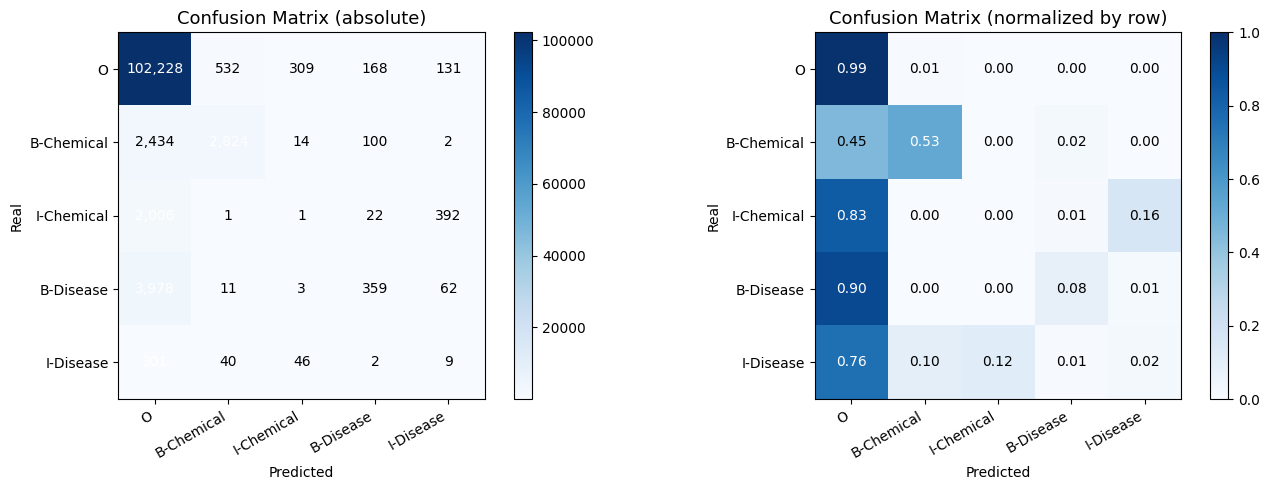

Guardado: confusion_matrix.png


In [44]:
from collections import defaultdict

categorias = ['O', 'B-Chemical', 'I-Chemical', 'B-Disease', 'I-Disease']
matriz = defaultdict(int)

for true_seq, pred_seq in zip(true_labels, true_preds):
    for t, p in zip(true_seq, pred_seq):
        matriz[(t, p)] += 1

n = len(categorias)
cm = np.zeros((n, n), dtype=int)
for i, t in enumerate(categorias):
    for j, p in enumerate(categorias):
        cm[i][j] = matriz[(t, p)]

cm_norm = cm.astype(float)
for i in range(n):
    if cm[i].sum() > 0:
        cm_norm[i] = cm[i] / cm[i].sum()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Confusion Matrix (absolute)', fontsize=13)
axes[0].set_xticks(range(n))
axes[0].set_yticks(range(n))
axes[0].set_xticklabels(categorias, rotation=30, ha='right')
axes[0].set_yticklabels(categorias)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Real')
plt.colorbar(im1, ax=axes[0])

for i in range(n):
    for j in range(n):
        axes[0].text(j, i, f'{cm[i,j]:,}',
                    ha='center', va='center',
                    color='white' if cm_norm[i,j] > 0.5 else 'black',
                    fontsize=10)

# Matriz normalizada
im2 = axes[1].imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (normalized by row)', fontsize=13)
axes[1].set_xticks(range(n))
axes[1].set_yticks(range(n))
axes[1].set_xticklabels(categorias, rotation=30, ha='right')
axes[1].set_yticklabels(categorias)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Real')
plt.colorbar(im2, ax=axes[1])

for i in range(n):
    for j in range(n):
        axes[1].text(j, i, f'{cm_norm[i,j]:.2f}',
                    ha='center', va='center',
                    color='white' if cm_norm[i,j] > 0.5 else 'black',
                    fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: confusion_matrix.png")

Para complementar el análisis cuantitativo, examinamos ejemplos concretos donde el modelo falla. Mostramos frases del test set donde hay discrepancias entre la predicción y la etiqueta real, lo que permite identificar patrones cualitativos de error.



In [42]:
print("=== EJEMPLOS DE ERRORES CUALITATIVOS ===\n")

tokens_test = [item["tokens"] for item in bc5cdr_test]
ejemplos_mostrados = 0

for tokens, true_seq, pred_seq in zip(tokens_test, true_labels, true_preds):
    if true_seq != pred_seq and ejemplos_mostrados < 5:
        print(f"Tokens: {' '.join(tokens)}")
        print(f"Real:   {true_seq}")
        print(f"Pred:   {pred_seq}")

        # Identificar diferencias
        diffs = [(i, t, p) for i, (t, p) in enumerate(zip(true_seq, pred_seq)) if t != p]
        for idx, t, p in diffs:
            print(f"  → Token '{tokens[idx]}': real={t}, predicho={p}")
        print()
        ejemplos_mostrados += 1

=== EJEMPLOS DE ERRORES CUALITATIVOS ===

Tokens: Famotidine - associated delirium .
Real:   ['B-Chemical', 'O', 'O', 'B-Disease', 'O']
Pred:   ['O', 'O', 'O', 'O', 'O']
  → Token 'Famotidine': real=B-Chemical, predicho=O
  → Token 'delirium': real=B-Disease, predicho=O

Tokens: Famotidine is a histamine H2 - receptor antagonist used in inpatient settings for prevention of stress ulcers and is showing increasing popularity because of its low cost .
Real:   ['B-Chemical', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Pred:   ['B-Chemical', 'O', 'O', 'B-Chemical', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
  → Token 'histamine': real=O, predicho=B-Chemical
  → Token 'stress': real=O, predicho=B-Disease
  → Token 'ulcers': real=B-Disease, predicho=O

Tokens: Although all of the currently available H2 - recepto

Finalizamos el análisis con una tabla comparativa completa de todos los modelos, incluyendo el baseline. Esta tabla es la pieza central del informe y permite responder las dos preguntas de investigación: el efecto del volumen de datos sintéticos y el efecto del diseño del prompt.



=== TABLA COMPARATIVA FINAL ===

           Modelo       F1
Baseline (BC5CDR) 0.884639
           ZS-800 0.317553
          FSA-800 0.339150
          FSB-100 0.035878
          FSB-500 0.322384
          FSB-800 0.370456


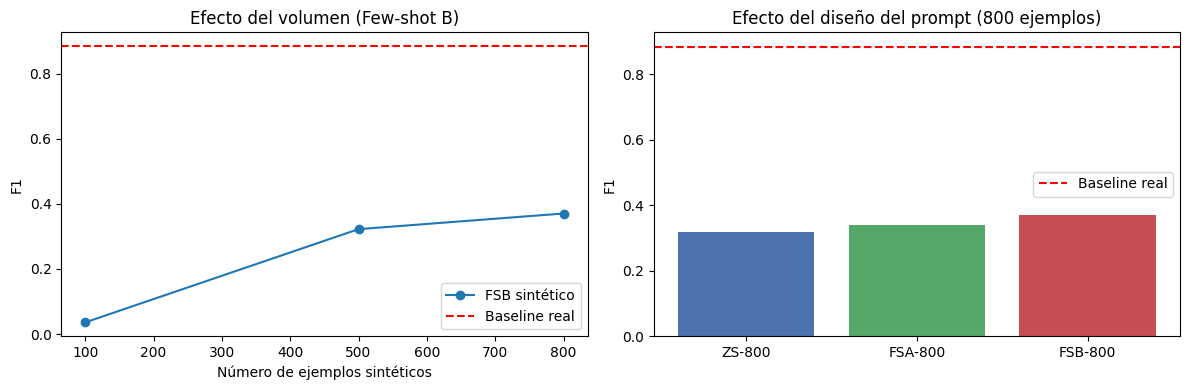

Guardado: resultados_finales.csv y resultados_graficos.png


In [43]:
import matplotlib.pyplot as plt

resultados_df = pd.DataFrame([
    {"Modelo": "Baseline (BC5CDR)",  "F1": res_baseline["eval_f1"],  "Datos": "Real",     "Volumen": len(bc5cdr_train)},
    {"Modelo": "ZS-800",             "F1": res_zs_800["eval_f1"],    "Datos": "Sintético", "Volumen": 800},
    {"Modelo": "FSA-800",            "F1": res_fsa_800["eval_f1"],   "Datos": "Sintético", "Volumen": 800},
    {"Modelo": "FSB-100",            "F1": res_fsb_100["eval_f1"],   "Datos": "Sintético", "Volumen": 100},
    {"Modelo": "FSB-500",            "F1": res_fsb_500["eval_f1"],   "Datos": "Sintético", "Volumen": 500},
    {"Modelo": "FSB-800",            "F1": res_fsb_800["eval_f1"],   "Datos": "Sintético", "Volumen": 800},
])

print("=== TABLA COMPARATIVA FINAL ===\n")
print(resultados_df[["Modelo", "F1"]].to_string(index=False))

# Gráfico curva de volumen
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Eje 1: volumen
volumenes = [100, 500, 800]
f1_volumen = [res_fsb_100["eval_f1"], res_fsb_500["eval_f1"], res_fsb_800["eval_f1"]]
ax1.plot(volumenes, f1_volumen, marker="o", label="FSB sintético")
ax1.axhline(res_baseline["eval_f1"], color="red", linestyle="--", label="Baseline real")
ax1.set_xlabel("Número de ejemplos sintéticos")
ax1.set_ylabel("F1")
ax1.set_title("Efecto del volumen (Few-shot B)")
ax1.legend()

# Eje 2: prompt
prompts = ["ZS-800", "FSA-800", "FSB-800"]
f1_prompts = [res_zs_800["eval_f1"], res_fsa_800["eval_f1"], res_fsb_800["eval_f1"]]
ax2.bar(prompts, f1_prompts, color=["#4C72B0", "#55A868", "#C44E52"])
ax2.axhline(res_baseline["eval_f1"], color="red", linestyle="--", label="Baseline real")
ax2.set_ylabel("F1")
ax2.set_title("Efecto del diseño del prompt (800 ejemplos)")
ax2.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/resultados_graficos.png", dpi=150)
plt.show()

resultados_df.to_csv("/kaggle/working/resultados_finales.csv", index=False)
print("Guardado: resultados_finales.csv y resultados_graficos.png")